# Notebook 07 : Validation temporelle du modèle avec `transfer`

Objectif : évaluer le modèle principal **avec le terme `transfer`** sur le groupe d’ancrage anonymisé 2017–2019, en utilisant exactement les seuils fixés dans le Notebook 03.

## Principe

| Élément | Source |
|---|---|
| Modèle final | `models/best_model.pkl` |
| Prétraitements | artefacts sauvegardés par le Notebook 03 |
| Seuil de pré-alerte | `seuil_alerte` dans `model_metadata.json` |
| Seuil standard | 0,500 |
| Seuil fort | `seuil_fort` dans `model_metadata.json` |
| Groupe évalué | groupe d’ancrage anonymisé 2017–2019 |

> Le seuil de pré-alerte n’est jamais recalculé dans ce notebook. Il est sélectionné sur la validation interne dans le Notebook 03, puis appliqué sans modification au test interne et au groupe d’ancrage.


---
## 1. Imports


In [1]:
import gc
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix, hstack
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

print("Imports OK")


Imports OK


---
## 2. Configuration et chemins


In [ ]:
RANDOM_STATE = 42
N_BOOT = 2000
CHUNKSIZE = 25_000

np.random.seed(RANDOM_STATE)

TARGET = "target"
SEUIL_STANDARD = 0.50


def trouver_racine_projet(reperes=("data", "results", "models", "notebooks")):
    """Retourne le premier dossier courant ou parent contenant un repère du projet."""
    for dossier in (Path.cwd(), *Path.cwd().parents):
        if any((dossier / repere).is_dir() for repere in reperes):
            return dossier
    return Path.cwd()


ROOT_DIR = trouver_racine_projet()
OUT_DIR = ROOT_DIR / "data" / "processed"
FIG_DIR = ROOT_DIR / "figures"
RESULT_DIR = ROOT_DIR / "results"
TABLE_DIR = RESULT_DIR / "tables"
MODEL_DIR = ROOT_DIR / "models"

for dossier in (OUT_DIR, FIG_DIR, RESULT_DIR, TABLE_DIR, MODEL_DIR):
    dossier.mkdir(parents=True, exist_ok=True)

DATA_PATH = OUT_DIR / "cohort_nlp.csv"
TEST_METRICS_PATH = RESULT_DIR / "metrics_meilleur_modele.csv"

#print("Racine du projet :", ROOT_DIR)
#print("Cohorte attendue  :", DATA_PATH)


Racine du projet : C:\Users\wdois\Desktop\Memoire_SDA7
Cohorte attendue  : C:\Users\wdois\Desktop\Memoire_SDA7\data\processed\cohort_nlp.csv


---
## 3. Chargement du modèle, des prétraitements et des seuils


In [3]:
artefacts = {
    "model": MODEL_DIR / "best_model.pkl",
    "tfidf": MODEL_DIR / "tfidf_vectorizer.pkl",
    "imputer": MODEL_DIR / "best_imputer.pkl",
    "scaler": MODEL_DIR / "best_scaler.pkl",
    "features": MODEL_DIR / "best_features.pkl",
    "metadata": MODEL_DIR / "model_metadata.json",
}

fichiers_manquants = [
    str(path) for path in artefacts.values() if not path.exists()
]

if fichiers_manquants:
    raise FileNotFoundError(
        "Artefacts manquants :\n- " + "\n- ".join(fichiers_manquants) +
        "\nRelancer le Notebook 03 avant le Notebook 07."
    )

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cohorte introuvable : {DATA_PATH}\n"
        "Relancer les Notebooks 01 et 02."
    )

model = joblib.load(artefacts["model"])
tfidf = joblib.load(artefacts["tfidf"])
imputer = joblib.load(artefacts["imputer"])
scaler = joblib.load(artefacts["scaler"])
features_num = list(joblib.load(artefacts["features"]))

with open(artefacts["metadata"], "r", encoding="utf-8") as f:
    metadata = json.load(f)

print("Artefacts chargés")
print("Type du modèle :", type(model).__name__)
print("Variables structurées attendues :", len(features_num))


Artefacts chargés
Type du modèle : MLPClassifier
Variables structurées attendues : 32


In [4]:
def lire_seuil_strict(meta, cles, libelle):
    """Lit un seuil dans les métadonnées sans utiliser de valeur par défaut silencieuse."""
    for cle in cles:
        valeur = meta.get(cle)
        if valeur is not None:
            valeur = float(valeur)
            if not 0 < valeur < 1:
                raise ValueError(
                    f"{libelle} invalide dans la clé '{cle}' : {valeur}"
                )
            return valeur, cle

    raise KeyError(
        f"{libelle} absent des métadonnées. Clés recherchées : {cles}. "
        "Relancer le Notebook 03 afin de sauvegarder les seuils définitifs."
    )


seuil_alerte, cle_seuil_alerte = lire_seuil_strict(
    metadata,
    ["seuil_alerte", "seuil_alerte_final"],
    "Seuil de pré-alerte",
)

seuil_fort, cle_seuil_fort = lire_seuil_strict(
    metadata,
    ["seuil_fort", "seuil_fort_final"],
    "Seuil fort",
)

if not (0 < seuil_alerte < SEUIL_STANDARD < seuil_fort < 1):
    raise ValueError(
        "Ordre des seuils incohérent : "
        f"pré-alerte={seuil_alerte:.6f}, "
        f"standard={SEUIL_STANDARD:.6f}, "
        f"fort={seuil_fort:.6f}."
    )

VALID_PERIOD = str(metadata.get("valid_period", "2017 - 2019"))
TEXT_COL = str(metadata.get("text_column_used", "cleaned_complaint"))
TEXT_MODEL_COL = TEXT_COL

version_finale = metadata.get(
    "model_name",
    metadata.get("algo_opt", "modèle sauvegardé par le Notebook 03"),
)

SEUILS_REFERENCE = {
    "pré-alerte": float(seuil_alerte),
    "standard": float(SEUIL_STANDARD),
    "fort": float(seuil_fort),
}

controle_seuils = pd.DataFrame([
    {
        "Type_seuil": "pré-alerte",
        "Seuil": seuil_alerte,
        "Source": f"model_metadata.json : {cle_seuil_alerte}",
    },
    {
        "Type_seuil": "standard",
        "Seuil": SEUIL_STANDARD,
        "Source": "valeur conventionnelle fixée à 0,500",
    },
    {
        "Type_seuil": "fort",
        "Seuil": seuil_fort,
        "Source": f"model_metadata.json : {cle_seuil_fort}",
    },
])

print("Modèle :", version_finale)
print("Période :", VALID_PERIOD)
display(controle_seuils.style.format({"Seuil": "{:.6f}"}))


Modèle : Modèle 3 — Variables structurées NB01 + NLP (MLP)
Période : 2017 - 2019


,Type_seuil,Seuil,Source
0,pré-alerte,0.217000,model_metadata.json : seuil_alerte
1,standard,0.500000,"valeur conventionnelle fixée à 0,500"
2,fort,0.650000,model_metadata.json : seuil_fort


In [5]:
# Vérification de la cohérence avec le fichier de métriques du test interne.
# Le notebook s’arrête si le seuil clinique enregistré dans ce fichier
# ne correspond pas au seuil lu dans model_metadata.json.

metrics_test = None

if TEST_METRICS_PATH.exists():
    metrics_test = pd.read_csv(TEST_METRICS_PATH)

    if "Seuil" not in metrics_test.columns:
        raise ValueError(
            f"La colonne 'Seuil' est absente de {TEST_METRICS_PATH.name}."
        )

    type_col = "Type_seuil" if "Type_seuil" in metrics_test.columns else None

    if type_col:
        masque_clinique = (
            metrics_test[type_col]
            .astype(str)
            .str.contains("clin|alerte|90", case=False, regex=True)
        )
    else:
        masque_clinique = np.isclose(
            pd.to_numeric(metrics_test["Seuil"], errors="coerce"),
            seuil_alerte,
            atol=1e-12,
        )

    lignes_cliniques = metrics_test.loc[masque_clinique].copy()

    if lignes_cliniques.empty:
        raise ValueError(
            "Aucune ligne clinique trouvée dans metrics_meilleur_modele.csv."
        )

    seuil_test_enregistre = float(lignes_cliniques.iloc[0]["Seuil"])

    if not np.isclose(
        seuil_test_enregistre,
        seuil_alerte,
        rtol=0,
        atol=5e-7,
    ):
        raise ValueError(
            "Incohérence de seuil entre les fichiers : "
            f"métadonnées={seuil_alerte:.6f}, "
            f"metrics_meilleur_modele.csv={seuil_test_enregistre:.6f}. "
            "Relancer le Notebook 03 puis reprendre ce notebook depuis le début."
        )

    print(
        "Cohérence du seuil clinique confirmée : "
        f"{seuil_alerte:.6f}"
    )
else:
    print(
        "Attention : metrics_meilleur_modele.csv est absent. "
        "La comparaison avec le test interne ne sera pas produite."
    )


Cohérence du seuil clinique confirmée : 0.217000


---
## 4. Préparation de la cohorte


In [6]:
header = pd.read_csv(DATA_PATH, nrows=0, engine="python").columns.tolist()
header_set = set(header)

colonnes_base = [
    "subject_id",
    "stay_id",
    "intime",
    "anchor_year_group",
    TARGET,
    TEXT_COL,
    "age_ed",
    "anchor_age",
    "gender",
    "arrival_transport",
    "acuity",
]

colonnes_voulues = list(dict.fromkeys(
    [col for col in colonnes_base + features_num if col in header_set]
))

colonnes_obligatoires = [
    "subject_id",
    "anchor_year_group",
    TARGET,
    TEXT_COL,
]

colonnes_manquantes = [
    col for col in colonnes_obligatoires
    if col not in colonnes_voulues
]

if colonnes_manquantes:
    raise ValueError(
        f"Colonnes obligatoires absentes de cohort_nlp.csv : "
        f"{colonnes_manquantes}"
    )

dtypes = {
    "heartrate": "float32",
    "sbp": "float32",
    "dbp": "float32",
    "o2sat": "float32",
    "resprate": "float32",
    "temperature": "float32",
    "pain": "float32",
    "age_ed": "float32",
    "anchor_age": "float32",
    "n_hosp_anterieures": "float32",
    "charlson_score_simplifie": "float32",
    "charlson_score": "float32",
    "acuity": "float32",
}

dtypes = {
    col: dtype for col, dtype in dtypes.items()
    if col in colonnes_voulues
}

print("Colonnes lues :", len(colonnes_voulues))
print("Colonne texte :", TEXT_COL)


Colonnes lues : 34
Colonne texte : cleaned_complaint


---
## 5. Fonctions de préparation, de prédiction et de métriques


In [7]:
def safe_div(numerateur, denominateur):
    return float(numerateur / denominateur) if denominateur else np.nan


def nettoyer_cible(df):
    """Sécurise la cible et l’identifiant patient."""
    df = df.copy()
    df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
    df["subject_id"] = pd.to_numeric(
        df["subject_id"],
        errors="coerce",
    )
    df = df.dropna(subset=[TARGET, "subject_id"]).copy()
    df[TARGET] = df[TARGET].astype("int8")
    df["subject_id"] = df["subject_id"].astype("int64")
    return df


def garder_groupe_ancrage(df):
    """Conserve le groupe d’ancrage correspondant à la période demandée."""
    df = df.copy()

    debut_periode = int(
        str(VALID_PERIOD).split("-")[0].strip()
    )

    annee_debut = pd.to_numeric(
        df["anchor_year_group"]
        .astype(str)
        .str.extract(r"(\d{4})", expand=False),
        errors="coerce",
    )

    masque = annee_debut.ge(debut_periode).fillna(False)
    return df.loc[masque].copy()


def normaliser_modalite(serie):
    """Normalise les modalités catégorielles comme dans le Notebook 03."""
    return (
        serie.fillna("missing")
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
        .replace("", "missing")
    )


def ajouter_dummies_nb03(df):
    """Reconstruit les variables indicatrices attendues par le modèle."""
    df = df.copy()

    for col in ["gender", "arrival_transport"]:
        if col not in df.columns:
            continue

        modalites = normaliser_modalite(df[col])
        dummies = pd.get_dummies(
            modalites,
            prefix=col,
            dtype="int8",
        )

        anciennes = [
            c for c in df.columns
            if c.startswith(f"{col}_")
        ]

        if anciennes:
            df = df.drop(columns=anciennes)

        df = pd.concat([df, dummies], axis=1)

    return df


def completer_variables(df):
    """Aligne les colonnes sur best_features.pkl."""
    df = ajouter_dummies_nb03(df)

    for col in features_num:
        if col not in df.columns:
            df[col] = 0.0

    return df


def matrice_numerique(df):
    """Construit la matrice structurée dans l’ordre attendu."""
    colonnes = []

    for col in features_num:
        serie = pd.to_numeric(df[col], errors="coerce")
        colonnes.append(
            serie.to_numpy(dtype="float64", copy=False)
        )

    return np.column_stack(colonnes)


In [8]:
def extraire_sortie(df, proba):
    """Conserve les colonnes nécessaires aux analyses."""
    colonnes = [
        "subject_id",
        "stay_id",
        "intime",
        "anchor_year_group",
        TARGET,
        "age_ed",
        "anchor_age",
        "gender",
        "arrival_transport",
        "acuity",
        TEXT_COL,
    ]

    colonnes = list(dict.fromkeys(
        [col for col in colonnes if col in df.columns]
    ))

    sortie = df.loc[:, colonnes].copy()
    sortie = sortie.loc[:, ~sortie.columns.duplicated()].copy()
    sortie["proba_hospitalisation"] = np.asarray(
        proba,
        dtype="float32",
    )
    return sortie


def predire_chunk(df):
    """Prépare un bloc du CSV et calcule les probabilités."""
    df = nettoyer_cible(df)
    df = garder_groupe_ancrage(df)

    if df.empty:
        return pd.DataFrame()

    df[TEXT_MODEL_COL] = (
        df[TEXT_COL]
        .fillna("")
        .astype(str)
    )

    df = completer_variables(df)

    X_num = matrice_numerique(df)
    X_num = imputer.transform(X_num)
    X_num = scaler.transform(X_num)

    X_txt = tfidf.transform(
        df[TEXT_MODEL_COL].fillna("")
    )

    X = hstack(
        [csr_matrix(X_num), X_txt],
        format="csr",
    )

    try:
        proba = model.predict_proba(X)[:, 1]
    except (TypeError, ValueError):
        proba = model.predict_proba(X.toarray())[:, 1]

    sortie = extraire_sortie(df, proba)

    del X_num, X_txt, X
    gc.collect()

    return sortie


def metriques_seuil(y, p, seuil):
    """Calcule les métriques à un seuil donné."""
    pred = (np.asarray(p) >= seuil).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y,
        pred,
        labels=[0, 1],
    ).ravel()

    return {
        "Seuil": float(seuil),
        "N": int(len(y)),
        "Admissions": int(tp + fn),
        "Alertes": int(tp + fp),
        "VP": int(tp),
        "VN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "Se": safe_div(tp, tp + fn),
        "Sp": safe_div(tn, tn + fp),
        "VPP": safe_div(tp, tp + fp),
        "VPN": safe_div(tn, tn + fn),
        "FNR": safe_div(fn, tp + fn),
        "FPR": safe_div(fp, fp + tn),
    }


---
## 6. Prédiction sur le groupe d’ancrage 2017–2019


In [9]:
predictions = []

lecteur = pd.read_csv(
    DATA_PATH,
    usecols=colonnes_voulues,
    dtype=dtypes,
    chunksize=CHUNKSIZE,
    engine="python",
    on_bad_lines="skip",
)

for numero_bloc, chunk in enumerate(lecteur, start=1):
    prediction_chunk = predire_chunk(chunk)

    if not prediction_chunk.empty:
        predictions.append(prediction_chunk)

    if numero_bloc % 10 == 0:
        print(f"{numero_bloc} blocs traités")

if not predictions:
    raise ValueError(
        "Aucune observation du groupe d’ancrage n’a été trouvée."
    )

prediction_df = pd.concat(
    predictions,
    ignore_index=True,
)

prediction_df = prediction_df.loc[
    :,
    ~prediction_df.columns.duplicated(),
].copy()

del predictions
gc.collect()

print(
    f"Groupe d’ancrage prédit : "
    f"{len(prediction_df):,} passages"
)


10 blocs traités
Groupe d’ancrage prédit : 67,963 passages


In [10]:
y_true = (
    prediction_df[TARGET]
    .astype(int)
    .to_numpy()
)

y_proba = (
    prediction_df["proba_hospitalisation"]
    .astype("float64")
    .to_numpy()
)

if len(np.unique(y_true)) != 2:
    raise ValueError(
        "La cible du groupe d’ancrage ne contient pas les deux classes."
    )

auc_ancrage = roc_auc_score(y_true, y_proba)
ap_ancrage = average_precision_score(y_true, y_proba)
brier_ancrage = brier_score_loss(y_true, y_proba)
prevalence_ancrage = float(y_true.mean())

performance_globale = pd.DataFrame([{
    "Jeu": f"Groupe d’ancrage {VALID_PERIOD}",
    "N": len(y_true),
    "Admissions": int(y_true.sum()),
    "Prevalence": prevalence_ancrage,
    "AUC": auc_ancrage,
    "Average_precision": ap_ancrage,
    "Brier": brier_ancrage,
}])

display(
    performance_globale.style.format({
        "Prevalence": "{:.3f}",
        "AUC": "{:.4f}",
        "Average_precision": "{:.4f}",
        "Brier": "{:.4f}",
    })
)


,Jeu,N,Admissions,Prevalence,AUC,Average_precision,Brier
0,Groupe d’ancrage 2017 - 2019,67963,26453,0.389,0.8875,0.8406,0.1324


### 6.1. Comparateur fondé sur le score ESI


In [11]:
auc_esi = np.nan
n_esi = 0

if "acuity" in prediction_df.columns:
    acuity_num = pd.to_numeric(
        prediction_df["acuity"],
        errors="coerce",
    )

    masque_esi = acuity_num.notna()
    n_esi = int(masque_esi.sum())

    y_esi = y_true[masque_esi.to_numpy()]
    score_esi = (
        6 - acuity_num.loc[masque_esi]
    ).to_numpy(dtype=float)

    if n_esi > 0 and len(np.unique(y_esi)) == 2:
        auc_esi = roc_auc_score(y_esi, score_esi)

comparaison_auc = pd.DataFrame([
    {
        "Comparateur": "Modèle final avec transfer",
        "N": len(y_true),
        "AUC": auc_ancrage,
    },
    {
        "Comparateur": "Score ESI seul",
        "N": n_esi,
        "AUC": auc_esi,
    },
])

display(
    comparaison_auc.style.format({
        "AUC": "{:.4f}",
    })
)


,Comparateur,N,AUC
0,Modèle final avec transfer,67963,0.8875
1,Score ESI seul,67957,0.7063


---
## 7. Métriques aux seuils exacts


In [12]:
seuils_grille = np.unique(np.r_[
    np.arange(0.05, 0.951, 0.05),
    list(SEUILS_REFERENCE.values()),
])

analyse_seuils = pd.DataFrame([
    metriques_seuil(y_true, y_proba, seuil)
    for seuil in seuils_grille
]).sort_values("Seuil").reset_index(drop=True)

resume_seuils = pd.DataFrame([
    {
        "Seuil_type": libelle,
        **metriques_seuil(y_true, y_proba, seuil),
    }
    for libelle, seuil in SEUILS_REFERENCE.items()
])

display(
    resume_seuils.style.format({
        "Seuil": "{:.6f}",
        "Se": "{:.4f}",
        "Sp": "{:.4f}",
        "VPP": "{:.4f}",
        "VPN": "{:.4f}",
        "FNR": "{:.4f}",
        "FPR": "{:.4f}",
    })
)


,Seuil_type,Seuil,N,Admissions,Alertes,VP,VN,FP,FN,Se,Sp,VPP,VPN,FNR,FPR
0,pré-alerte,0.217000,67963,26453,36278,23450,28682,12828,3003,0.8865,0.6910,0.6464,0.9052,0.1135,0.3090
1,standard,0.500000,67963,26453,22945,18216,36781,4729,8237,0.6886,0.8861,0.7939,0.8170,0.3114,0.1139
2,fort,0.650000,67963,26453,17668,15057,38899,2611,11396,0.5692,0.9371,0.8522,0.7734,0.4308,0.0629


In [13]:
# Indicateurs standardisés pour 100 passages.

for table in (analyse_seuils, resume_seuils):
    table["Alertes_pour_100"] = table["Alertes"] / table["N"] * 100
    table["VP_pour_100"] = table["VP"] / table["N"] * 100
    table["FP_pour_100"] = table["FP"] / table["N"] * 100
    table["FN_pour_100"] = table["FN"] / table["N"] * 100

colonnes_affichage = [
    "Seuil_type",
    "Seuil",
    "Se",
    "Sp",
    "VPP",
    "VPN",
    "Alertes_pour_100",
    "VP_pour_100",
    "FP_pour_100",
    "FN_pour_100",
]

display(
    resume_seuils[colonnes_affichage].style.format({
        "Seuil": "{:.6f}",
        "Se": "{:.3f}",
        "Sp": "{:.3f}",
        "VPP": "{:.3f}",
        "VPN": "{:.3f}",
        "Alertes_pour_100": "{:.1f}",
        "VP_pour_100": "{:.1f}",
        "FP_pour_100": "{:.1f}",
        "FN_pour_100": "{:.1f}",
    })
)


,Seuil_type,Seuil,Se,Sp,VPP,VPN,Alertes_pour_100,VP_pour_100,FP_pour_100,FN_pour_100
0,pré-alerte,0.217000,0.886,0.691,0.646,0.905,53.4,34.5,18.9,4.4
1,standard,0.500000,0.689,0.886,0.794,0.817,33.8,26.8,7.0,12.1
2,fort,0.650000,0.569,0.937,0.852,0.773,26.0,22.2,3.8,16.8


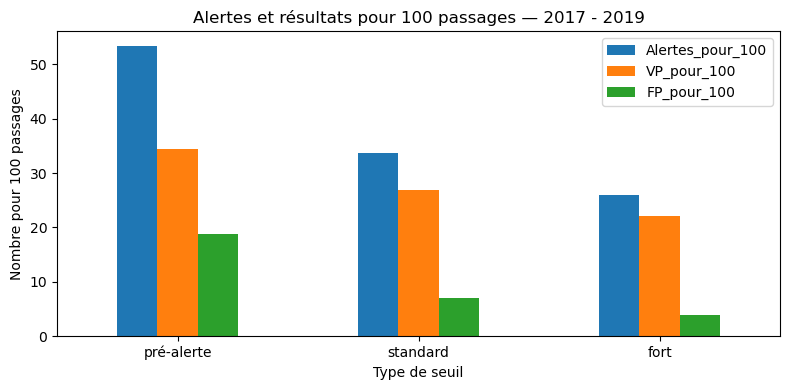

In [14]:
plot_seuils = (
    resume_seuils
    .set_index("Seuil_type")[[
        "Alertes_pour_100",
        "VP_pour_100",
        "FP_pour_100",
    ]]
)

ax = plot_seuils.plot(
    kind="bar",
    figsize=(8, 4),
)

ax.set_title(
    f"Alertes et résultats pour 100 passages — {VALID_PERIOD}"
)
ax.set_xlabel("Type de seuil")
ax.set_ylabel("Nombre pour 100 passages")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig41_indicateurs_100_passages_avec_transfer.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


---
## 8. Comparaison avec le test interne


In [15]:
def trouver_ligne_seuil(table, seuil, type_recherche=None):
    """Retourne une ligne correspondant au seuil demandé."""
    table = table.copy()

    valeurs_seuil = pd.to_numeric(
        table["Seuil"],
        errors="coerce",
    )

    masque = np.isclose(
        valeurs_seuil,
        seuil,
        rtol=0,
        atol=5e-7,
    )

    if type_recherche and "Type_seuil" in table.columns:
        masque_type = (
            table["Type_seuil"]
            .astype(str)
            .str.contains(
                type_recherche,
                case=False,
                regex=True,
            )
        )
        masque = masque | masque_type

    resultat = table.loc[masque]

    if resultat.empty:
        return None

    return resultat.iloc[0]


comparaison_jeux = pd.DataFrame()

if metrics_test is not None:
    test_standard = trouver_ligne_seuil(
        metrics_test,
        SEUIL_STANDARD,
        r"standard",
    )

    test_alerte = trouver_ligne_seuil(
        metrics_test,
        seuil_alerte,
        r"clin|alerte|90",
    )

    ancrage_standard = trouver_ligne_seuil(
        resume_seuils,
        SEUIL_STANDARD,
        r"standard",
    )

    ancrage_alerte = trouver_ligne_seuil(
        resume_seuils,
        seuil_alerte,
        r"pré-alerte",
    )

    if test_standard is None or test_alerte is None:
        raise ValueError(
            "Les lignes standard et pré-alerte sont incomplètes "
            "dans metrics_meilleur_modele.csv."
        )

    lignes_comparaison = []

    for jeu, ligne, type_seuil, auc_val, brier_val in [
        (
            "Test interne",
            test_standard,
            "standard",
            float(test_standard["AUC"]),
            float(test_standard["Brier"]),
        ),
        (
            "Groupe d’ancrage",
            ancrage_standard,
            "standard",
            auc_ancrage,
            brier_ancrage,
        ),
        (
            "Test interne",
            test_alerte,
            "pré-alerte",
            float(test_alerte["AUC"]),
            float(test_alerte["Brier"]),
        ),
        (
            "Groupe d’ancrage",
            ancrage_alerte,
            "pré-alerte",
            auc_ancrage,
            brier_ancrage,
        ),
    ]:
        lignes_comparaison.append({
            "Jeu": jeu,
            "Type_seuil": type_seuil,
            "Seuil": float(ligne["Seuil"]),
            "AUC": auc_val,
            "Brier": brier_val,
            "Se": float(ligne["Se"]),
            "Sp": float(ligne["Sp"]),
            "VPP": float(ligne["VPP"]),
            "VPN": float(ligne["VPN"]),
            "VP": int(ligne["VP"]),
            "VN": int(ligne["VN"]),
            "FP": int(ligne["FP"]),
            "FN": int(ligne["FN"]),
        })

    comparaison_jeux = pd.DataFrame(lignes_comparaison)

    display(
        comparaison_jeux.style.format({
            "Seuil": "{:.6f}",
            "AUC": "{:.4f}",
            "Brier": "{:.4f}",
            "Se": "{:.4f}",
            "Sp": "{:.4f}",
            "VPP": "{:.4f}",
            "VPN": "{:.4f}",
        })
    )
else:
    print("Comparaison non produite : fichier du test interne absent.")


,Jeu,Type_seuil,Seuil,AUC,Brier,Se,Sp,VPP,VPN,VP,VN,FP,FN
0,Test interne,standard,0.500000,0.8640,0.1448,0.6694,0.8611,0.7483,0.8086,15963,33297,5370,7883
1,Groupe d’ancrage,standard,0.500000,0.8875,0.1324,0.6886,0.8861,0.7939,0.8170,18216,36781,4729,8237
2,Test interne,pré-alerte,0.217000,0.8640,0.1448,0.9022,0.6111,0.5886,0.9102,21515,23628,15039,2331
3,Groupe d’ancrage,pré-alerte,0.217000,0.8875,0.1324,0.8865,0.6910,0.6464,0.9052,23450,28682,12828,3003


In [16]:
# Tableau de lecture directe, sans mélange entre le seuil 0,500
# et le seuil de pré-alerte.

comparaison_resume = pd.DataFrame()

if not comparaison_jeux.empty:
    lignes = []

    for type_seuil in ["standard", "pré-alerte"]:
        sous_table = comparaison_jeux[
            comparaison_jeux["Type_seuil"] == type_seuil
        ].set_index("Jeu")

        test = sous_table.loc["Test interne"]
        ancrage = sous_table.loc["Groupe d’ancrage"]

        for metrique in [
            "AUC", "Brier", "Se", "Sp", "VPP", "VPN"
        ]:
            valeur_test = float(test[metrique])
            valeur_ancrage = float(ancrage[metrique])

            lignes.append({
                "Type_seuil": type_seuil,
                "Seuil": float(test["Seuil"]),
                "Métrique": metrique,
                "Test_interne": valeur_test,
                "Groupe_ancrage": valeur_ancrage,
                "Delta": valeur_ancrage - valeur_test,
            })

        lignes.append({
            "Type_seuil": type_seuil,
            "Seuil": float(test["Seuil"]),
            "Métrique": "VP / VN / FP / FN",
            "Test_interne": (
                f"{int(test['VP'])} / {int(test['VN'])} / "
                f"{int(test['FP'])} / {int(test['FN'])}"
            ),
            "Groupe_ancrage": (
                f"{int(ancrage['VP'])} / {int(ancrage['VN'])} / "
                f"{int(ancrage['FP'])} / {int(ancrage['FN'])}"
            ),
            "Delta": "—",
        })

    comparaison_resume = pd.DataFrame(lignes)
    display(comparaison_resume)


,Type_seuil,Seuil,Métrique,Test_interne,Groupe_ancrage,Delta
0,standard,0.500,AUC,0.863976,0.887474,0.023497
1,standard,0.500,Brier,0.144828,0.132396,-0.012432
2,standard,0.500,Se,0.66942,0.688618,0.019197
3,standard,0.500,Sp,0.861122,0.886076,0.024954
4,standard,0.500,VPP,0.748277,0.793898,0.045621
5,standard,0.500,VPN,0.808572,0.817029,0.008457
6,standard,0.500,VP / VN / FP / FN,15963 / 33297 / 5370 / 7883,18216 / 36781 / 4729 / 8237,—
7,pré-alerte,0.217,AUC,0.863976,0.887474,0.023497
8,pré-alerte,0.217,Brier,0.144828,0.132396,-0.012432
9,pré-alerte,0.217,Se,0.902248,0.886478,-0.01577


---
## 9. Intervalles de confiance par bootstrap


In [17]:
def bootstrap_metrics(
    y,
    p,
    seuil,
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
):
    """Bootstrap stratifié sur les classes."""
    rng = np.random.default_rng(random_state)

    index_0 = np.flatnonzero(y == 0)
    index_1 = np.flatnonzero(y == 1)

    aucs = np.empty(n_boot, dtype=float)
    sensibilites = np.empty(n_boot, dtype=float)
    specificites = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        index_boot = np.concatenate([
            rng.choice(
                index_0,
                size=len(index_0),
                replace=True,
            ),
            rng.choice(
                index_1,
                size=len(index_1),
                replace=True,
            ),
        ])

        y_boot = y[index_boot]
        p_boot = p[index_boot]
        pred_boot = (p_boot >= seuil).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_boot,
            pred_boot,
            labels=[0, 1],
        ).ravel()

        aucs[i] = roc_auc_score(y_boot, p_boot)
        sensibilites[i] = safe_div(tp, tp + fn)
        specificites[i] = safe_div(tn, tn + fp)

    metriques = metriques_seuil(y, p, seuil)

    return {
        "N_boot": int(n_boot),
        "Seuil": float(seuil),
        "AUC": float(roc_auc_score(y, p)),
        "AUC_IC95_inf": float(np.percentile(aucs, 2.5)),
        "AUC_IC95_sup": float(np.percentile(aucs, 97.5)),
        "Se": float(metriques["Se"]),
        "Se_IC95_inf": float(np.percentile(sensibilites, 2.5)),
        "Se_IC95_sup": float(np.percentile(sensibilites, 97.5)),
        "Sp": float(metriques["Sp"]),
        "Sp_IC95_inf": float(np.percentile(specificites, 2.5)),
        "Sp_IC95_sup": float(np.percentile(specificites, 97.5)),
    }


print(
    f"Bootstrap stratifié : {N_BOOT} itérations "
    f"au seuil {seuil_alerte:.6f}"
)

bootstrap_resultats = bootstrap_metrics(
    y_true,
    y_proba,
    seuil_alerte,
)

bootstrap_table = pd.DataFrame([bootstrap_resultats])

display(
    bootstrap_table.style.format({
        "Seuil": "{:.6f}",
        "AUC": "{:.4f}",
        "AUC_IC95_inf": "{:.4f}",
        "AUC_IC95_sup": "{:.4f}",
        "Se": "{:.4f}",
        "Se_IC95_inf": "{:.4f}",
        "Se_IC95_sup": "{:.4f}",
        "Sp": "{:.4f}",
        "Sp_IC95_inf": "{:.4f}",
        "Sp_IC95_sup": "{:.4f}",
    })
)


Bootstrap stratifié : 2000 itérations au seuil 0.217000


,N_boot,Seuil,AUC,AUC_IC95_inf,AUC_IC95_sup,Se,Se_IC95_inf,Se_IC95_sup,Sp,Sp_IC95_inf,Sp_IC95_sup
0,2000,0.217000,0.8875,0.8851,0.8900,0.8865,0.8825,0.8903,0.6910,0.6867,0.6953


---
## 10. Classes de risque


In [18]:
bins_risque = [
    0.0,
    seuil_alerte,
    SEUIL_STANDARD,
    seuil_fort,
    np.nextafter(1.0, 2.0),
]

labels_risque = [
    "faible",
    "intermédiaire",
    "élevé",
    "très élevé",
]

prediction_df["classe_risque"] = pd.cut(
    prediction_df["proba_hospitalisation"],
    bins=bins_risque,
    labels=labels_risque,
    include_lowest=True,
    right=False,
)

classes_risque = (
    prediction_df
    .groupby("classe_risque", observed=True)
    .agg(
        n=(TARGET, "size"),
        hospitalisations=(TARGET, "sum"),
        proba_moyenne=("proba_hospitalisation", "mean"),
        taux_hospitalisation=(TARGET, "mean"),
    )
    .reset_index()
)

classes_risque["part_population"] = (
    classes_risque["n"] / len(prediction_df)
)

print("Bornes exactes :", bins_risque)
display(
    classes_risque.style.format({
        "proba_moyenne": "{:.3f}",
        "taux_hospitalisation": "{:.3f}",
        "part_population": "{:.3f}",
    })
)


Bornes exactes : [0.0, 0.217, 0.5, 0.65, np.float64(1.0000000000000002)]


,classe_risque,n,hospitalisations,proba_moyenne,taux_hospitalisation,part_population
0,faible,31685,3003,0.072,0.095,0.466
1,intermédiaire,13333,5234,0.347,0.393,0.196
2,élevé,5277,3159,0.573,0.599,0.078
3,très élevé,17668,15057,0.850,0.852,0.260


---
## 11. Stratégies fondées sur un nombre d’alertes pour 100 passages


In [19]:
def strategie_top_n_pour_100(data, n_pour_100):
    """Sélectionne les scores les plus élevés."""
    n_selection = int(
        round(len(data) * n_pour_100 / 100)
    )

    n_selection = max(
        1,
        min(n_selection, len(data)),
    )

    seuil_implicite = float(
        data["proba_hospitalisation"]
        .nlargest(n_selection)
        .min()
    )

    metriques = metriques_seuil(
        data[TARGET].to_numpy(),
        data["proba_hospitalisation"].to_numpy(),
        seuil_implicite,
    )

    metriques["Top_N_pour_100"] = n_pour_100
    metriques["Seuil_implicite"] = seuil_implicite
    metriques["Alertes_pour_100"] = (
        metriques["Alertes"] / metriques["N"] * 100
    )
    return metriques


topn_table = pd.DataFrame([
    strategie_top_n_pour_100(prediction_df, n)
    for n in [5, 10, 15, 20, 30, 40, 50]
])

display(
    topn_table[[
        "Top_N_pour_100",
        "Seuil_implicite",
        "Se",
        "Sp",
        "VPP",
        "VPN",
        "Alertes_pour_100",
    ]].style.format({
        "Seuil_implicite": "{:.6f}",
        "Se": "{:.3f}",
        "Sp": "{:.3f}",
        "VPP": "{:.3f}",
        "VPN": "{:.3f}",
        "Alertes_pour_100": "{:.1f}",
    })
)


,Top_N_pour_100,Seuil_implicite,Se,Sp,VPP,VPN,Alertes_pour_100
0,5,0.957783,0.125,0.998,0.976,0.642,5.0
1,10,0.902254,0.245,0.993,0.955,0.674,10.0
2,15,0.835050,0.357,0.982,0.925,0.705,15.0
3,20,0.756117,0.459,0.965,0.894,0.737,20.0
4,30,0.570013,0.633,0.912,0.821,0.796,30.0
5,40,0.392450,0.766,0.834,0.746,0.848,40.0
6,50,0.257209,0.861,0.730,0.671,0.892,50.0


---
## 12. Calibration


In [20]:
def table_calibration(y, p, n_bins=10):
    table = pd.DataFrame({
        "y": y,
        "p": p,
    })

    table["decile"] = pd.qcut(
        table["p"],
        q=n_bins,
        duplicates="drop",
    )

    calibration = (
        table
        .groupby("decile", observed=True)
        .agg(
            n=("y", "size"),
            proba_moyenne=("p", "mean"),
            taux_observe=("y", "mean"),
        )
        .reset_index()
    )

    calibration["erreur_absolue"] = (
        calibration["taux_observe"] -
        calibration["proba_moyenne"]
    ).abs()

    ece = float(
        (
            calibration["n"] /
            calibration["n"].sum() *
            calibration["erreur_absolue"]
        ).sum()
    )

    return calibration, ece


calibration_deciles, ece_ancrage = table_calibration(
    y_true,
    y_proba,
)

print(f"Brier : {brier_ancrage:.4f}")
print(f"ECE   : {ece_ancrage:.4f}")

display(
    calibration_deciles.style.format({
        "proba_moyenne": "{:.4f}",
        "taux_observe": "{:.4f}",
        "erreur_absolue": "{:.4f}",
    })
)


Brier : 0.1324
ECE   : 0.0221


,decile,n,proba_moyenne,taux_observe,erreur_absolue
0,"(-0.000989, 0.0152]",6797,0.0063,0.0088,0.0025
1,"(0.0152, 0.0424]",6796,0.0282,0.0384,0.0102
2,"(0.0424, 0.0854]",6796,0.0619,0.0809,0.0191
3,"(0.0854, 0.154]",6796,0.1174,0.1610,0.0436
4,"(0.154, 0.257]",6797,0.2019,0.2501,0.0482
5,"(0.257, 0.392]",6796,0.3220,0.3698,0.0478
6,"(0.392, 0.57]",6796,0.4790,0.5199,0.0408
7,"(0.57, 0.756]",6796,0.6664,0.6750,0.0086
8,"(0.756, 0.902]",6796,0.8330,0.8331,0.0001
9,"(0.902, 1.0]",6797,0.9554,0.9553,0.0001


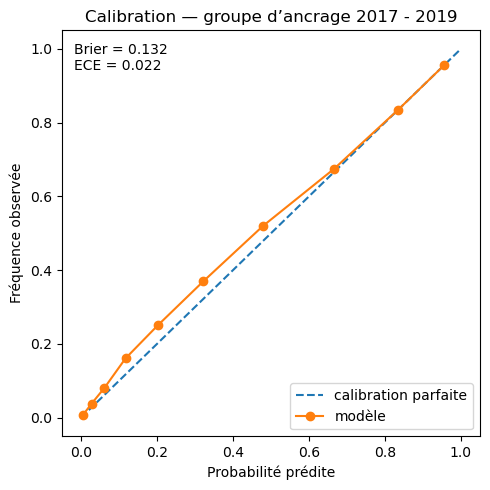

In [21]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="calibration parfaite",
)

ax.plot(
    calibration_deciles["proba_moyenne"],
    calibration_deciles["taux_observe"],
    marker="o",
    label="modèle",
)

ax.set_title(
    f"Calibration — groupe d’ancrage {VALID_PERIOD}"
)
ax.set_xlabel("Probabilité prédite")
ax.set_ylabel("Fréquence observée")
ax.legend()

ax.text(
    0.03,
    0.97,
    f"Brier = {brier_ancrage:.3f}\nECE = {ece_ancrage:.3f}",
    transform=ax.transAxes,
    va="top",
    ha="left",
)

fig.tight_layout()
fig.savefig(
    FIG_DIR / "fig42_calibration_deciles_avec_transfer.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


---
## 13. Analyse du terme `transfer`


In [22]:
motif_transfer = (
    prediction_df[TEXT_COL]
    .fillna("")
    .astype(str)
    .str.contains(
        r"\btransfer\w*\b",
        case=False,
        regex=True,
    )
)

prediction_df["contient_transfer"] = motif_transfer

lignes_transfer = []

for libelle, masque in [
    ("avec le terme transfer", motif_transfer),
    ("sans le terme transfer", ~motif_transfer),
]:
    sous_groupe = prediction_df.loc[masque]

    if sous_groupe.empty:
        continue

    y_groupe = sous_groupe[TARGET].astype(int).to_numpy()
    p_groupe = (
        sous_groupe["proba_hospitalisation"]
        .astype(float)
        .to_numpy()
    )

    auc_groupe = (
        roc_auc_score(y_groupe, p_groupe)
        if len(np.unique(y_groupe)) == 2
        else np.nan
    )

    metriques_groupe_transfer = metriques_seuil(
        y_groupe,
        p_groupe,
        seuil_alerte,
    )

    lignes_transfer.append({
        "Groupe": libelle,
        "N": len(sous_groupe),
        "Part_population": len(sous_groupe) / len(prediction_df),
        "Taux_hospitalisation": float(y_groupe.mean()),
        "AUC": auc_groupe,
        "Seuil": seuil_alerte,
        "Se": metriques_groupe_transfer["Se"],
        "Sp": metriques_groupe_transfer["Sp"],
        "VPP": metriques_groupe_transfer["VPP"],
        "VPN": metriques_groupe_transfer["VPN"],
        "VP": metriques_groupe_transfer["VP"],
        "VN": metriques_groupe_transfer["VN"],
        "FP": metriques_groupe_transfer["FP"],
        "FN": metriques_groupe_transfer["FN"],
    })

analyse_transfer = pd.DataFrame(lignes_transfer)

display(
    analyse_transfer.style.format({
        "Part_population": "{:.3f}",
        "Taux_hospitalisation": "{:.3f}",
        "AUC": "{:.3f}",
        "Seuil": "{:.6f}",
        "Se": "{:.3f}",
        "Sp": "{:.3f}",
        "VPP": "{:.3f}",
        "VPN": "{:.3f}",
    })
)


,Groupe,N,Part_population,Taux_hospitalisation,AUC,Seuil,Se,Sp,VPP,VPN,VP,VN,FP,FN
0,avec le terme transfer,9446,0.139,0.811,0.803,0.217000,0.996,0.046,0.818,0.732,7635,82,1699,30
1,sans le terme transfer,58517,0.861,0.321,0.870,0.217000,0.842,0.720,0.587,0.906,15815,28600,11129,2973


---
## 14. Analyse par sous-groupes


In [23]:
def metriques_groupe(data, variable, seuil, min_n=100):
    lignes = []

    for modalite, sous_groupe in data.groupby(
        variable,
        dropna=False,
        observed=False,
    ):
        if len(sous_groupe) < min_n:
            continue

        y = (
            sous_groupe[TARGET]
            .astype(int)
            .to_numpy()
        )

        p = (
            sous_groupe["proba_hospitalisation"]
            .astype(float)
            .to_numpy()
        )

        m = metriques_seuil(y, p, seuil)

        auc_groupe = (
            roc_auc_score(y, p)
            if len(np.unique(y)) == 2
            else np.nan
        )

        lignes.append({
            "Variable": variable,
            "Modalite": str(modalite),
            "N": len(sous_groupe),
            "Taux_hospitalisation": float(y.mean()),
            "AUC": auc_groupe,
            "Se": m["Se"],
            "Sp": m["Sp"],
            "VPP": m["VPP"],
            "VPN": m["VPN"],
            "FN": m["FN"],
            "FP": m["FP"],
            "Seuil": float(seuil),
        })

    return pd.DataFrame(lignes)


In [24]:
age_col = (
    "age_ed"
    if "age_ed" in prediction_df.columns
    else "anchor_age"
)

prediction_df["groupe_age"] = pd.cut(
    pd.to_numeric(
        prediction_df[age_col],
        errors="coerce",
    ),
    bins=[18, 40, 65, 80, np.inf],
    labels=[
        "moins de 40 ans",
        "40 à 64 ans",
        "65 à 79 ans",
        "80 ans et plus",
    ],
    right=False,
)

variables_sous_groupes = [
    col for col in [
        "groupe_age",
        "gender",
        "acuity",
    ]
    if col in prediction_df.columns
]

tables_sous_groupes = [
    metriques_groupe(
        prediction_df,
        variable,
        seuil_alerte,
    )
    for variable in variables_sous_groupes
]

subgroup_metrics = (
    pd.concat(
        tables_sous_groupes,
        ignore_index=True,
    )
    if tables_sous_groupes
    else pd.DataFrame()
)

if not subgroup_metrics.empty:
    se_globale = float(
        resume_seuils.loc[
            resume_seuils["Seuil_type"] == "pré-alerte",
            "Se",
        ].iloc[0]
    )

    subgroup_metrics["Delta_Se_vs_global"] = (
        subgroup_metrics["Se"] - se_globale
    )

    subgroup_metrics["Delta_AUC_vs_global"] = (
        subgroup_metrics["AUC"] - auc_ancrage
    )

    subgroup_metrics["Alerte_Se"] = (
        subgroup_metrics["Delta_Se_vs_global"].abs() > 0.10
    )

    subgroup_metrics["Alerte_AUC"] = (
        subgroup_metrics["Delta_AUC_vs_global"].abs() > 0.05
    )

if subgroup_metrics.empty:
    display(subgroup_metrics)
else:
    display(
        subgroup_metrics.style.format({
            "Taux_hospitalisation": "{:.3f}",
            "AUC": "{:.3f}",
            "Se": "{:.3f}",
            "Sp": "{:.3f}",
            "VPP": "{:.3f}",
            "VPN": "{:.3f}",
            "Seuil": "{:.6f}",
            "Delta_Se_vs_global": "{:+.3f}",
            "Delta_AUC_vs_global": "{:+.3f}",
        })
    )


,Variable,Modalite,N,Taux_hospitalisation,AUC,Se,Sp,VPP,VPN,FN,FP,Seuil,Delta_Se_vs_global,Delta_AUC_vs_global,Alerte_Se,Alerte_AUC
0,groupe_age,moins de 40 ans,27440,0.180,0.863,0.698,0.840,0.489,0.927,1488,3604,0.217000,-0.188,-0.024,True,False
1,groupe_age,40 à 64 ans,21944,0.428,0.854,0.887,0.597,0.623,0.876,1063,5055,0.217000,+0.000,-0.033,False,False
2,groupe_age,65 à 79 ans,12237,0.618,0.842,0.953,0.407,0.722,0.842,356,2773,0.217000,+0.066,-0.045,False,False
3,groupe_age,80 ans et plus,6342,0.718,0.831,0.979,0.219,0.762,0.803,96,1396,0.217000,+0.092,-0.056,False,True
4,gender,F,35647,0.365,0.886,0.862,0.726,0.643,0.901,1797,6215,0.217000,-0.025,-0.001,False,False
5,gender,M,32316,0.416,0.888,0.910,0.649,0.649,0.910,1206,6613,0.217000,+0.024,+0.000,False,False
6,acuity,1.0,2041,0.736,0.877,0.983,0.266,0.789,0.851,25,395,0.217000,+0.097,-0.010,False,False
7,acuity,2.0,24746,0.597,0.845,0.962,0.339,0.683,0.859,555,6605,0.217000,+0.076,-0.042,False,False
8,acuity,3.0,35981,0.281,0.854,0.768,0.775,0.571,0.895,2343,5814,0.217000,-0.119,-0.034,True,False
9,acuity,4.0,5027,0.018,0.879,0.136,0.998,0.522,0.985,76,11,0.217000,-0.750,-0.008,True,False


---
## 15. Faux négatifs au seuil de pré-alerte


In [25]:
prediction_df["alerte_precoce"] = (
    prediction_df["proba_hospitalisation"] >=
    seuil_alerte
)

faux_negatifs = prediction_df.loc[
    (prediction_df[TARGET] == 1) &
    (~prediction_df["alerte_precoce"])
].copy()

part_fn_hospitalises = (
    len(faux_negatifs) /
    max(1, int(y_true.sum()))
)

print(
    f"Seuil utilisé : {seuil_alerte:.6f}"
)
print(
    f"Faux négatifs : {len(faux_negatifs):,}"
)
print(
    "Part des hospitalisations non signalées : "
    f"{part_fn_hospitalises:.1%}"
)


Seuil utilisé : 0.217000
Faux négatifs : 3,003
Part des hospitalisations non signalées : 11.4%


In [26]:
texte_fn = faux_negatifs.loc[:, TEXT_COL]

if isinstance(texte_fn, pd.DataFrame):
    texte_fn = texte_fn.iloc[:, 0]

fn_motifs = (
    texte_fn
    .fillna("")
    .astype(str)
    .str.strip()
    .value_counts()
    .head(20)
    .rename_axis("motif")
    .reset_index(name="n")
)

display(fn_motifs)


,motif,n
0,chest pain,106
1,abdominal pain,87
2,headache,66
3,wound eval,66
4,flank pain,56
5,rlq abdominal pain,56
6,chest pain dyspnea,45
7,low pain,43
8,pain,41
9,abdominal pain nausea vomit,33


---
## 16. Courbe de décision (DCA)

La DCA est calculée sur une grille continue **et aux trois seuils exacts** utilisés dans le reste du notebook : pré-alerte, standard et fort.


In [27]:
def benefice_net_modele(y, p, seuil):
    """Bénéfice net du modèle à un seuil donné."""
    pred = (np.asarray(p) >= seuil).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y,
        pred,
        labels=[0, 1],
    ).ravel()

    n = len(y)
    poids_fp = seuil / (1 - seuil)

    return (
        tp / n -
        fp / n * poids_fp
    )


def benefice_net_tous(prevalence, seuil):
    """Bénéfice net de la stratégie consistant à signaler tous les patients."""
    return (
        prevalence -
        (1 - prevalence) *
        seuil / (1 - seuil)
    )


grille_dca = np.unique(np.r_[
    np.arange(0.01, 0.951, 0.01),
    list(SEUILS_REFERENCE.values()),
])

dca = pd.DataFrame({
    "Seuil": grille_dca,
})

dca["Modele"] = [
    benefice_net_modele(
        y_true,
        y_proba,
        seuil,
    )
    for seuil in dca["Seuil"]
]

dca["Signaler_tous"] = [
    benefice_net_tous(
        prevalence_ancrage,
        seuil,
    )
    for seuil in dca["Seuil"]
]

dca["Signaler_personne"] = 0.0

dca_seuils_exacts = pd.DataFrame([
    {
        "Type_seuil": libelle,
        "Seuil": seuil,
        "Benefice_net_modele": benefice_net_modele(
            y_true,
            y_proba,
            seuil,
        ),
        "Benefice_net_signaler_tous": benefice_net_tous(
            prevalence_ancrage,
            seuil,
        ),
        "Benefice_net_signaler_personne": 0.0,
    }
    for libelle, seuil in SEUILS_REFERENCE.items()
])

dca_seuils_exacts["Gain_vs_tous"] = (
    dca_seuils_exacts["Benefice_net_modele"] -
    dca_seuils_exacts["Benefice_net_signaler_tous"]
)

dca_seuils_exacts["Gain_vs_personne"] = (
    dca_seuils_exacts["Benefice_net_modele"]
)

display(
    dca_seuils_exacts.style.format({
        "Seuil": "{:.6f}",
        "Benefice_net_modele": "{:.5f}",
        "Benefice_net_signaler_tous": "{:.5f}",
        "Benefice_net_signaler_personne": "{:.5f}",
        "Gain_vs_tous": "{:+.5f}",
        "Gain_vs_personne": "{:+.5f}",
    })
)


,Type_seuil,Seuil,Benefice_net_modele,Benefice_net_signaler_tous,Benefice_net_signaler_personne,Gain_vs_tous,Gain_vs_personne
0,pré-alerte,0.217000,0.29273,0.21996,0.00000,+0.07277,+0.29273
1,standard,0.500000,0.19845,-0.22155,0.00000,+0.41999,+0.19845
2,fort,0.650000,0.15020,-0.74507,0.00000,+0.89527,+0.15020


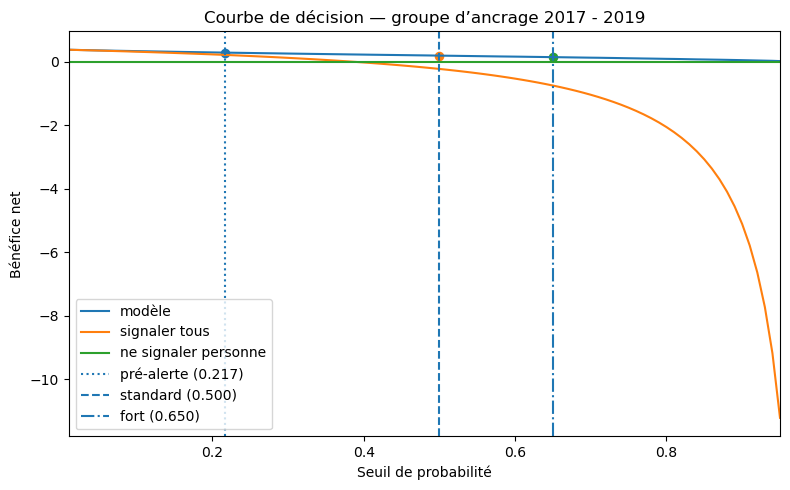

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    dca["Seuil"],
    dca["Modele"],
    label="modèle",
)

ax.plot(
    dca["Seuil"],
    dca["Signaler_tous"],
    label="signaler tous",
)

ax.plot(
    dca["Seuil"],
    dca["Signaler_personne"],
    label="ne signaler personne",
)

styles = {
    "pré-alerte": ":",
    "standard": "--",
    "fort": "-.",
}

for libelle, seuil in SEUILS_REFERENCE.items():
    benefice = benefice_net_modele(
        y_true,
        y_proba,
        seuil,
    )

    ax.axvline(
        seuil,
        linestyle=styles[libelle],
        label=f"{libelle} ({seuil:.3f})",
    )

    ax.scatter(
        [seuil],
        [benefice],
        s=35,
    )

ax.set_title(
    f"Courbe de décision — groupe d’ancrage {VALID_PERIOD}"
)
ax.set_xlabel("Seuil de probabilité")
ax.set_ylabel("Bénéfice net")
ax.set_xlim(0.01, 0.95)
ax.legend()
fig.tight_layout()

fig.savefig(
    FIG_DIR / "fig43_dca_avec_transfer_seuils_exacts.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


---
## 17. Sauvegarde des résultats


In [29]:
# Fichiers principaux, avec des noms explicites.
prediction_df.to_csv(
    RESULT_DIR / "validation_predictions_avec_transfer.csv",
    index=False,
)

performance_globale.to_csv(
    TABLE_DIR / "performance_globale_ancrage_avec_transfer.csv",
    index=False,
)

comparaison_auc.to_csv(
    TABLE_DIR / "comparaison_auc_modele_esi_avec_transfer.csv",
    index=False,
)

analyse_transfer.to_csv(
    TABLE_DIR / "analyse_terme_transfer.csv",
    index=False,
)

controle_seuils.to_csv(
    TABLE_DIR / "controle_seuils_avec_transfer.csv",
    index=False,
)

analyse_seuils.to_csv(
    TABLE_DIR / "analyse_seuils_avec_transfer.csv",
    index=False,
)

resume_seuils.to_csv(
    TABLE_DIR / "resume_seuils_avec_transfer.csv",
    index=False,
)

classes_risque.to_csv(
    TABLE_DIR / "classes_risque_avec_transfer.csv",
    index=False,
)

topn_table.to_csv(
    TABLE_DIR / "strategie_topN_avec_transfer.csv",
    index=False,
)

calibration_deciles.to_csv(
    TABLE_DIR / "calibration_deciles_avec_transfer.csv",
    index=False,
)

subgroup_metrics.to_csv(
    TABLE_DIR / "sous_groupes_avec_transfer.csv",
    index=False,
)

fn_motifs.to_csv(
    TABLE_DIR / "faux_negatifs_motifs_avec_transfer.csv",
    index=False,
)

bootstrap_table.to_csv(
    TABLE_DIR / "bootstrap_ancrage_avec_transfer.csv",
    index=False,
)

dca.to_csv(
    TABLE_DIR / "dca_courbe_avec_transfer.csv",
    index=False,
)

dca_seuils_exacts.to_csv(
    TABLE_DIR / "dca_seuils_exacts_avec_transfer.csv",
    index=False,
)

if not comparaison_jeux.empty:
    comparaison_jeux.to_csv(
        TABLE_DIR / "comparaison_test_ancrage_avec_transfer.csv",
        index=False,
    )

if not comparaison_resume.empty:
    comparaison_resume.to_csv(
        TABLE_DIR / "comparaison_test_ancrage_format_lecture.csv",
        index=False,
    )

# Alias conservés pour ne pas casser les autres notebooks déjà écrits.
analyse_seuils.to_csv(
    TABLE_DIR / "tab7_analyse_seuils_op_avec.csv",
    index=False,
)

resume_seuils.to_csv(
    TABLE_DIR / "tab8_resume_seuils_op_avec.csv",
    index=False,
)

classes_risque.to_csv(
    TABLE_DIR / "tab9_classes_risque_op_avec.csv",
    index=False,
)

calibration_deciles.to_csv(
    TABLE_DIR / "tab4_calibration_deciles_avec_op.csv",
    index=False,
)

dca.to_csv(
    TABLE_DIR / "tab44_decision_curve_avec.csv",
    index=False,
)

print("Sauvegarde terminée")
#print("Dossier des tableaux :", TABLE_DIR)
#print("Dossier des figures  :", FIG_DIR)


Sauvegarde terminée
Dossier des tableaux : C:\Users\wdois\Desktop\Memoire_SDA7\results\tables
Dossier des figures  : C:\Users\wdois\Desktop\Memoire_SDA7\figures


In [30]:
# Mise à jour d’un fichier synthétique pour le mémoire et les articles.

resultats_cles_path = RESULT_DIR / "resultats_cles.json"

if resultats_cles_path.exists():
    with open(
        resultats_cles_path,
        "r",
        encoding="utf-8",
    ) as f:
        resultats_cles = json.load(f)
else:
    resultats_cles = {}

ligne_alerte = resume_seuils.loc[
    resume_seuils["Seuil_type"] == "pré-alerte"
].iloc[0]

resultats_cles.update({
    "modele_retenu": version_finale,
    "seuil_alerte": float(seuil_alerte),
    "seuil_standard": float(SEUIL_STANDARD),
    "seuil_fort": float(seuil_fort),
    "auc_validation_temp": float(auc_ancrage),
    "average_precision_validation_temp": float(ap_ancrage),
    "brier_validation_temp": float(brier_ancrage),
    "ece_validation_temp": float(ece_ancrage),
    "sensibilite_seuil_alerte": float(ligne_alerte["Se"]),
    "specificite_seuil_alerte": float(ligne_alerte["Sp"]),
    "vpp_seuil_alerte": float(ligne_alerte["VPP"]),
    "vpn_seuil_alerte": float(ligne_alerte["VPN"]),
    "vp_seuil_alerte": int(ligne_alerte["VP"]),
    "vn_seuil_alerte": int(ligne_alerte["VN"]),
    "fp_seuil_alerte": int(ligne_alerte["FP"]),
    "fn_seuil_alerte": int(ligne_alerte["FN"]),
})

for _, ligne in dca_seuils_exacts.iterrows():
    cle = (
        str(ligne["Type_seuil"])
        .replace("é", "e")
        .replace("è", "e")
        .replace("-", "_")
        .replace(" ", "_")
    )

    resultats_cles[
        f"dca_benefice_net_{cle}"
    ] = float(ligne["Benefice_net_modele"])

with open(
    resultats_cles_path,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        resultats_cles,
        f,
        ensure_ascii=False,
        indent=2,
    )

print(
    f"{resultats_cles_path.name} mis à jour : "
    f"{len(resultats_cles)} clés"
)


resultats_cles.json mis à jour : 26 clés


---
## 18. Vérification des éléments de rapport TRIPOD+AI


In [31]:
tripod_items = [
    {
        "Domaine": "Source des données",
        "Élément": "MIMIC-IV-ED et conditions de réutilisation décrites",
        "Statut": "à documenter dans l’article",
    },
    {
        "Domaine": "Population",
        "Élément": "Critères d’inclusion et d’exclusion avec diagramme de flux",
        "Statut": "à documenter dans l’article",
    },
    {
        "Domaine": "Prédicteurs",
        "Élément": "Variables structurées et TF-IDF décrits",
        "Statut": "présent dans les Notebooks 02 et 03",
    },
    {
        "Domaine": "Valeurs manquantes",
        "Élément": "Imputation ajustée uniquement sur le train",
        "Statut": "contrôlé par les artefacts du Notebook 03",
    },
    {
        "Domaine": "Validation",
        "Élément": "Groupe d’ancrage anonymisé 2017–2019 tenu à l’écart",
        "Statut": "validation interne et temporelle approximative",
    },
    {
        "Domaine": "Performance",
        "Élément": "AUC, calibration et métriques aux seuils",
        "Statut": "calculé dans ce notebook",
    },
    {
        "Domaine": "Sous-groupes",
        "Élément": "Âge, sexe et niveau de triage",
        "Statut": "calculé dans ce notebook",
    },
    {
        "Domaine": "Utilité décisionnelle",
        "Élément": "Courbe de décision aux seuils exacts",
        "Statut": "calculé dans ce notebook",
    },
    {
        "Domaine": "Validation externe",
        "Élément": "Évaluation sur un autre établissement",
        "Statut": "non réalisée — limite à déclarer",
    },
]

df_tripod = pd.DataFrame(tripod_items)
display(df_tripod)

df_tripod.to_csv(
    TABLE_DIR / "checklist_tripod_ai_avec_transfer.csv",
    index=False,
)


,Domaine,Élément,Statut
0,Source des données,MIMIC-IV-ED et conditions de réutilisation déc...,à documenter dans l’article
1,Population,Critères d’inclusion et d’exclusion avec diagr...,à documenter dans l’article
2,Prédicteurs,Variables structurées et TF-IDF décrits,présent dans les Notebooks 02 et 03
3,Valeurs manquantes,Imputation ajustée uniquement sur le train,contrôlé par les artefacts du Notebook 03
4,Validation,Groupe d’ancrage anonymisé 2017–2019 tenu à l’...,validation interne et temporelle approximative
5,Performance,"AUC, calibration et métriques aux seuils",calculé dans ce notebook
6,Sous-groupes,"Âge, sexe et niveau de triage",calculé dans ce notebook
7,Utilité décisionnelle,Courbe de décision aux seuils exacts,calculé dans ce notebook
8,Validation externe,Évaluation sur un autre établissement,non réalisée — limite à déclarer


In [33]:
# Checklist TRIPOD+AI 
# Cette étude suit les recommandations TRIPOD+AI (Collins et al., BMJ 2024)
# pour le signalement des modèles de prédiction basés sur l'IA.
# Référence : Collins GS, Moons KGM, Dhiman P, et al. TRIPOD+AI statement: updated guidance
# for reporting clinical prediction models that use regression or machine learning methods.
# BMJ. 2024;385:e078378.

tripod_items = [
    # TITRE ET RÉSUMÉ
    ('1a', 'Titre',             'Identification comme modèle de prédiction',        True,  'Titre du mémoire explicite'),
    ('1b', 'Résumé structuré',  'Résumé avec métriques principales et IC 95%',      True,  'Résumé contient AUC, Se, Sp, Brier, IC bootstrap'),
    # INTRODUCTION
    ('2',  'Contexte',          'Justification clinique et objectif du modèle',      True,  'Introduction chapitres 1-2'),
    ('3',  'Objectifs',         'Précision population cible et outcome prédit',       True,  'Hospitalisation depuis triage — adultes ≥18 ans'),
    # MÉTHODES
    ('4a', 'Source données',    'Description de la base MIMIC-IV ED',               True,  'NB01 — BIDMC, PhysioNet, conditions accès'),
    ('4b', 'Participants',      'Critères inclusion/exclusion + flowchart',          True,  'NB01 — flowchart 4 étapes, 383 919 séjours'),
    ('4c', 'Outcome',           'Définition précise de la variable cible',           True,  'ADMITTED=1, HOME=0, ambiguïtés exclues'),
    ('5',  'Prédicteurs',       'Variables utilisées et leur source',                True,  'NB03 — variables structurées + 1000 TF-IDF'),
    ('6',  'Taille échantillon','Justification de la taille',                       True,  '383 919 séjours, 188 127 patients uniques'),
    ('7',  'Valeurs manquantes','Stratégie d\'imputation documentée',               True,  'Médiane sur train uniquement — NB01'),
    ('8',  'Analyse statistique','Méthodes ML, optimisation, critère sélection',     True,  'Sélection clinique : Se≥90 % puis Sp@Se90 ; seuil choisi sur validation interne'),
    ('9',  'Split & validation','Séparation temporelle stricte 2017-2019',           True,  'ayg_start < 2017 / ≥ 2017, GroupShuffleSplit'),
    ('10', 'Performance',       'Métriques multiples avec IC 95%',                   True,  'AUC, Se, Sp, VPP, VPN, Brier, ECE + bootstrap'),
    ('11', 'Calibration',       'Évaluation et correction de la calibration',        True,  'Calibration retenue dynamiquement uniquement si le Brier validation interne s’améliore'),
    ('12', 'Interprétabilité', 'Méthodes d\'explication du modèle',                True,  'Interprétabilité adaptée au modèle final ; pas d’importance Gini si MLP'),
    ('13', 'Équité (Fairness)', 'Analyse par sous-groupes démographiques',           True,  'NB07 — âge, genre, acuity'),
    # RÉSULTATS
    ('14', 'Participants',      'Description de la cohorte (Table 1)',               True,  'NB06 — Table 1 format revue'),
    ('15', 'Performances',      'Métriques avec IC 95% sur validation temporelle',      True,  'NB07 — bootstrap 2000 itérations'),
    ('16', 'Calibration',       'Courbe de calibration + Brier + ECE',               True,  'NB04/NB07 — Brier, ECE et courbe de calibration'),
    ('17', 'Décision clinique', 'DCA — bénéfice net vs stratégies limites',          True,  'NB07 — Decision Curve Analysis'),
    # DISCUSSION
    ('18', 'Limites',           'Limites du modèle et des données documentées',      True,  'Mémoire Partie IV Chapitre 13'),
    ('19', 'Généralisabilité',  'Conditions de déploiement et recalibration',        True,  'Mémoire Chapitre 14 — validation prospective'),
    # NON CONFORMITÉS
    ('20', 'Données biologiques','Résultats biologiques non disponibles au triage',  False, 'LIMITE : NB non disponible → FN structurel'),
    ('21', 'Validation externe','Monocentrique — pas de validation multi-sites',    False, 'LIMITE : BIDMC uniquement, transposabilité limitée'),
]

df_tripod = pd.DataFrame(tripod_items,
    columns=['Item', 'Domaine', 'Critère', 'Conforme', 'Note'])

print('=== TRIPOD+AI CHECKLIST ===')
print(f'{df_tripod["Conforme"].sum()} / {len(df_tripod)} items conformes')
print()
for _, r in df_tripod.iterrows():
    status = '**' if r['Conforme'] else '## LIMITE'
    print(f"  {status}  [{r['Item']:>3}] {r['Domaine']:<22} {r['Note'][:60]}")

df_tripod.to_csv(RESULT_DIR / 'tab46_tripod_ai_checklist_avec.csv', index=False)
print('\n tab46_tripod_ai_checklist_avec.csv sauvegardé')

# Résumé des limites TRIPOD non conformes 
non_conformes = df_tripod[~df_tripod['Conforme']]
if len(non_conformes):
    print('\n** Non-conformités à documenter explicitement dans les limites du mémoire :')
    for _, r in non_conformes.iterrows():
        print(f"  [{r['Item']}] {r['Domaine']} — {r['Note']}")

=== TRIPOD+AI CHECKLIST ===
22 / 24 items conformes

  **  [ 1a] Titre                  Titre du mémoire explicite
  **  [ 1b] Résumé structuré       Résumé contient AUC, Se, Sp, Brier, IC bootstrap
  **  [  2] Contexte               Introduction chapitres 1-2
  **  [  3] Objectifs              Hospitalisation depuis triage — adultes ≥18 ans
  **  [ 4a] Source données         NB01 — BIDMC, PhysioNet, conditions accès
  **  [ 4b] Participants           NB01 — flowchart 4 étapes, 383 919 séjours
  **  [ 4c] Outcome                ADMITTED=1, HOME=0, ambiguïtés exclues
  **  [  5] Prédicteurs            NB03 — variables structurées + 1000 TF-IDF
  **  [  6] Taille échantillon     383 919 séjours, 188 127 patients uniques
  **  [  7] Valeurs manquantes     Médiane sur train uniquement — NB01
  **  [  8] Analyse statistique    Sélection clinique : Se≥90 % puis Sp@Se90 ; seuil choisi sur
  **  [  9] Split & validation     ayg_start < 2017 / ≥ 2017, GroupShuffleSplit
  **  [ 10] Performance  

---
## 19. Contrôle final


In [32]:
print("=" * 72)
print("RÉSUMÉ FINAL — NOTEBOOK 07")
print("=" * 72)
print(f"Modèle                  : {version_finale}")
print(f"Groupe évalué           : {VALID_PERIOD}")
print(f"Nombre de passages      : {len(y_true):,}")
print(f"Taux d’hospitalisation  : {prevalence_ancrage:.1%}")
print(f"AUC                      : {auc_ancrage:.4f}")
print(f"Brier                    : {brier_ancrage:.4f}")
print(f"ECE                      : {ece_ancrage:.4f}")
print()
print(
    f"Seuil pré-alerte        : {seuil_alerte:.6f} "
    f"(source : {cle_seuil_alerte})"
)
print(f"Seuil standard          : {SEUIL_STANDARD:.6f}")
print(
    f"Seuil fort              : {seuil_fort:.6f} "
    f"(source : {cle_seuil_fort})"
)
print()
print("DCA calculée aux trois seuils exacts :")
for _, ligne in dca_seuils_exacts.iterrows():
    print(
        f"  {ligne['Type_seuil']:<12} "
        f"seuil={ligne['Seuil']:.6f}  "
        f"bénéfice net={ligne['Benefice_net_modele']:.5f}"
    )
print("=" * 72)


RÉSUMÉ FINAL — NOTEBOOK 07
Modèle                  : Modèle 3 — Variables structurées NB01 + NLP (MLP)
Groupe évalué           : 2017 - 2019
Nombre de passages      : 67,963
Taux d’hospitalisation  : 38.9%
AUC                      : 0.8875
Brier                    : 0.1324
ECE                      : 0.0221

Seuil pré-alerte        : 0.217000 (source : seuil_alerte)
Seuil standard          : 0.500000
Seuil fort              : 0.650000 (source : seuil_fort)

DCA calculée aux trois seuils exacts :
  pré-alerte   seuil=0.217000  bénéfice net=0.29273
  standard     seuil=0.500000  bénéfice net=0.19845
  fort         seuil=0.650000  bénéfice net=0.15020
